In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/drive/MyDrive/last_data_refined.csv')

In [5]:
df.head()

,ACCOUNT_ID,CARD_ID,TRANSACTION_ID,GROSS_TRANSACTION_AMOUNT,TRANSACTION_DATE,TRANSACTION_TYPE,TRANSACTION_STATE,TRANSACTION_CITY,MERCHANT_STATE,MERCHANT_CITY,...,CARD_HOLDER_GENERATION,CARD_HOLDER_TOTAL_TRANSACTION_COUNT,CARD_HOLDER_TOTAL_SPEND,CARD_HOLDER_AVERAGE_LTM_SPEND,CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT,CARD_HOLDER_VINTAGE,CARD_PRESENT_INDICATOR,MERCHANT_ID,MERCHANT_NAME,SHOPPER_CLASSIFICATION
0,A6184793,C7717436,T8535582,0.99,2024-03-13 06:46:55.000,Spend,OH,EUCLID,OH,WESTLAKE,...,Gen Z,443,8452.70,511.77,26.25,29,Card Not Present,112,WENDYS,0
1,A2296562,C5518346,T2383075,22.76,2024-05-16 20:34:18.000,Spend,MI,FORT GRATIOT,MI,FORT GRATIOT,...,Millennial,3382,115654.41,NaN,NaN,87,Card Present,214,JIMMY JOHNS GOURMET SANDWICHES,2
2,A5523719,C7179772,T7494465,8.84,2024-04-25 17:09:37.000,Spend,OH,TOLEDO,OH,TOLEDO,...,Gen Z,1999,48756.32,2400.99,100.33,25,Card Present,58,SUBWAY,0
3,A7905524,C1779514,T5897261,8.78,2024-05-26 13:50:06.000,Spend,IN,LAFAYETTE,IN,LAFAYETTE,...,Gen Z,449,10444.67,NaN,NaN,26,Card Not Present,37,MCDONALDS,0
4,A7846687,C8240547,T2709494,18.01,2024-05-05 19:54:35.000,Spend,MN,DELANO,MN,DELANO,...,Baby Boomer,551,16220.59,1513.71,51.27,10,Card Present,522,CULVERS,0


In [6]:
df.shape

(4771540, 27)

In [7]:
def apply_local_timezone(df):
    """
    TRANSACTION_STATE를 기반으로 UTC 시간을 각 지역의 정확한 현지 시간으로 변환하는 함수
    """
    print("시간대 변환을 시작합니다. (데이터 크기에 따라 수초~수십초 소요될 수 있습니다)")

    # 1. State별 주요 Timezone 매핑 딕셔너리
    # (일부 주에 2개의 시간대가 걸쳐있는 경우 가장 인구/상권이 많은 대표 시간대로 매핑했습니다)
    tz_mapping = {
        # Eastern Time (EST/EDT)
        'OH':'America/New_York', 'MI':'America/New_York', 'IN':'America/New_York', 'NC':'America/New_York',
        'FL':'America/New_York', 'VA':'America/New_York', 'MA':'America/New_York', 'SC':'America/New_York',
        'GA':'America/New_York', 'PA':'America/New_York', 'DE':'America/New_York', 'MD':'America/New_York',
        'NY':'America/New_York', 'CT':'America/New_York', 'WV':'America/New_York', 'RI':'America/New_York',
        'NJ':'America/New_York', 'DC':'America/New_York', 'ME':'America/New_York', 'VT':'America/New_York',
        'NH':'America/New_York',

        # Central Time (CST/CDT)
        'MN':'America/Chicago', 'WI':'America/Chicago', 'TX':'America/Chicago', 'LA':'America/Chicago',
        'IL':'America/Chicago', 'MS':'America/Chicago', 'TN':'America/Chicago', 'NE':'America/Chicago',
        'MO':'America/Chicago', 'AL':'America/Chicago', 'ND':'America/Chicago', 'OK':'America/Chicago',
        'IA':'America/Chicago', 'SD':'America/Chicago', 'AR':'America/Chicago', 'KS':'America/Chicago',

        # Mountain Time (MST/MDT)
        'CO':'America/Denver', 'UT':'America/Denver', 'NM':'America/Denver', 'ID':'America/Denver',
        'MT':'America/Denver', 'WY':'America/Denver',
        'AZ':'America/Phoenix', # 애리조나는 서머타임을 적용하지 않아 별도 분리

        # Pacific Time (PST/PDT)
        'CA':'America/Los_Angeles', 'NV':'America/Los_Angeles', 'WA':'America/Los_Angeles', 'OR':'America/Los_Angeles',

        # 기타 지역 및 해외 영토
        'AK':'America/Anchorage', 'HI':'Pacific/Honolulu',
        'PR':'America/Puerto_Rico', 'VI':'America/Puerto_Rico', 'GU':'Pacific/Guam', 'MP':'Pacific/Guam', 'AS':'Pacific/Pago_Pago',

        # 군사 우편번호(AE, AP, AA) 등은 임의로 UTC나 동부시간으로 설정
        'AE':'UTC', 'AP':'UTC', 'AA':'America/New_York'
    }

    # 2. TRANSACTION_DATE를 Datetime 객체로 변환하고 기본값을 UTC로 명시
    if not pd.api.types.is_datetime64_any_dtype(df['TRANSACTION_DATE']):
        df['TRANSACTION_DATE'] = pd.to_datetime(df['TRANSACTION_DATE'])

    if df['TRANSACTION_DATE'].dt.tz is None:
        df['TRANSACTION_DATE'] = df['TRANSACTION_DATE'].dt.tz_localize('UTC')

    # 3. 주(State)에 맞는 타임존 열 생성 (결측치는 우선 UTC로 처리)
    df['TZ_NAME'] = df['TRANSACTION_STATE'].map(tz_mapping).fillna('America/New_York')

    # 4. 각 타임존별로 변환 결과를 담을 빈 시리즈 생성
    local_times = pd.Series(index=df.index, dtype='datetime64[ns]')

    # 5. 각 고유 타임존별로 현지 시간 변환 (서머타임 자동 계산됨)
    for tz in df['TZ_NAME'].unique():
        mask = df['TZ_NAME'] == tz
        # 해당 지역의 시간으로 변환 후, 다시 tz-naive 형태로 껍데기를 벗겨야 한 컬럼에 합칠 수 있음
        local_times[mask] = df.loc[mask, 'TRANSACTION_DATE'].dt.tz_convert(tz).dt.tz_localize(None)

    # 6. 최종 컬럼 적용 및 요일/시간 추출
    df['LOCAL_TIME'] = local_times
    df['Hour'] = df['LOCAL_TIME'].dt.hour
    df['DayOfWeek'] = df['LOCAL_TIME'].dt.day_name()

    # 요일 순서 정렬
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    df['DayOfWeek'] = pd.Categorical(df['DayOfWeek'], categories=days_order, ordered=True)

    print("✅ 현지 시간(Local Time) 변환이 완료되었습니다!")
    return df

# 함수 실행하여 df 업데이트
df = apply_local_timezone(df)

시간대 변환을 시작합니다. (데이터 크기에 따라 수초~수십초 소요될 수 있습니다)
✅ 현지 시간(Local Time) 변환이 완료되었습니다!


In [8]:
print("drop 전 행 수:", len(df))
print("ACCOUNT_ID 결측 행 수:", df['ACCOUNT_ID'].isna().sum())

df = df.dropna(subset=['ACCOUNT_ID']).copy()

print("drop 후 행 수:", len(df))

drop 전 행 수: 4771540
ACCOUNT_ID 결측 행 수: 132420
drop 후 행 수: 4639120


In [ ]:
# 1. 분석에 사용할 핵심 컬럼
required_cols = [
    'ACCOUNT_ID',
    'TRANSACTION_DATE',
    'CARD_HOLDER_TOTAL_SPEND',
    'CARD_HOLDER_VINTAGE',
    'CARD_HOLDER_TOTAL_TRANSACTION_COUNT',
    'CARD_HOLDER_AVERAGE_LTM_SPEND',
    'CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT'
]

cluster_df = df[required_cols].copy()
cluster_df['TRANSACTION_DATE'] = pd.to_datetime(cluster_df['TRANSACTION_DATE'], errors='coerce')

numeric_cols = [
    'CARD_HOLDER_TOTAL_SPEND',
    'CARD_HOLDER_VINTAGE',
    'CARD_HOLDER_TOTAL_TRANSACTION_COUNT',
    'CARD_HOLDER_AVERAGE_LTM_SPEND',
    'CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT'
]

for col in numeric_cols:
    cluster_df[col] = pd.to_numeric(cluster_df[col], errors='coerce')


# 필요한 컬럼만 복사
cluster_df = df[required_cols].copy()

# 2. 날짜형 변환
cluster_df['TRANSACTION_DATE'] = pd.to_datetime(cluster_df['TRANSACTION_DATE'], errors='coerce')


# 3. 결측치 확인
missing_summary = pd.DataFrame({
    'missing_count': cluster_df.isnull().sum(),
    'missing_ratio(%)': (cluster_df.isnull().mean() * 100).round(2)
}).sort_values(by='missing_count', ascending=False)

print("\n[결측치 현황]")
print(missing_summary)


# 4. 기초 점검
print("\n[전체 행 수]")
print(len(cluster_df))

print("\n[고유 ACCOUNT_ID 수]")
print(cluster_df['ACCOUNT_ID'].nunique())

print("\n[TRANSACTION_DATE 범위]")
print("min:", cluster_df['TRANSACTION_DATE'].min())
print("max:", cluster_df['TRANSACTION_DATE'].max())

# 5. 평균 단가 계산 전 꼭 봐야 하는 값
zero_txn_count = (cluster_df['CARD_HOLDER_TOTAL_TRANSACTION_COUNT'] == 0).sum()
print("\n[CARD_HOLDER_TOTAL_TRANSACTION_COUNT == 0 개수]")
print(zero_txn_count)

# 음수값 여부도 같이 체크
for col in numeric_cols:
    neg_count = (cluster_df[col] < 0).sum()
    print(f"{col} 음수 개수: {neg_count}")


[결측치 현황]
                                           missing_count  missing_ratio(%)
CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT         615100             13.26
CARD_HOLDER_AVERAGE_LTM_SPEND                     615100             13.26
ACCOUNT_ID                                             0              0.00
CARD_HOLDER_TOTAL_SPEND                                0              0.00
TRANSACTION_DATE                                       0              0.00
CARD_HOLDER_TOTAL_TRANSACTION_COUNT                    0              0.00
CARD_HOLDER_VINTAGE                                    0              0.00

[전체 행 수]
4639120

[고유 ACCOUNT_ID 수]
3653447

[TRANSACTION_DATE 범위]
min: 2024-01-01 00:00:00+00:00
max: 2024-06-30 00:00:00+00:00

[CARD_HOLDER_TOTAL_TRANSACTION_COUNT == 0 개수]
0
CARD_HOLDER_TOTAL_SPEND 음수 개수: 0
CARD_HOLDER_VINTAGE 음수 개수: 0
CARD_HOLDER_TOTAL_TRANSACTION_COUNT 음수 개수: 0
CARD_HOLDER_AVERAGE_LTM_SPEND 음수 개수: 0
CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT 음수 개수: 0


In [ ]:
fill_base = df[['ACCOUNT_ID', 'TRANSACTION_DATE', 'GROSS_TRANSACTION_AMOUNT']].copy()
fill_base['TRANSACTION_DATE'] = pd.to_datetime(fill_base['TRANSACTION_DATE'], errors='coerce')
fill_base['GROSS_TRANSACTION_AMOUNT'] = pd.to_numeric(fill_base['GROSS_TRANSACTION_AMOUNT'], errors='coerce')


# 2024년 1~6월 ACCOUNT_ID별 월평균 spend / 월평균 거래횟수 계산
jan_jun_agg = (
    fill_base[
        (fill_base['TRANSACTION_DATE'] >= '2024-01-01') &
        (fill_base['TRANSACTION_DATE'] < '2024-07-01')
    ]
    .groupby('ACCOUNT_ID')
    .agg(
        FILL_LTM_SPEND=('GROSS_TRANSACTION_AMOUNT', 'sum'),
        FILL_LTM_TXN_COUNT=('ACCOUNT_ID', 'size')
    )
)

jan_jun_agg['FILL_LTM_SPEND'] = jan_jun_agg['FILL_LTM_SPEND'] / 6
jan_jun_agg['FILL_LTM_TXN_COUNT'] = jan_jun_agg['FILL_LTM_TXN_COUNT'] / 6

# cluster_df에 붙이기
cluster_df = cluster_df.merge(
    jan_jun_agg[['FILL_LTM_SPEND', 'FILL_LTM_TXN_COUNT']],
    left_on='ACCOUNT_ID',
    right_index=True,
    how='left'
)

# vintage < 12 인 경우 결측치 채우기
cond_lt_12 = cluster_df['CARD_HOLDER_VINTAGE'] < 12

mask1 = cond_lt_12 & cluster_df['CARD_HOLDER_AVERAGE_LTM_SPEND'].isna()
cluster_df.loc[mask1, 'CARD_HOLDER_AVERAGE_LTM_SPEND'] = (
    cluster_df.loc[mask1, 'CARD_HOLDER_TOTAL_SPEND'] /
    (cluster_df.loc[mask1, 'CARD_HOLDER_VINTAGE'] + 1)
)

mask2 = cond_lt_12 & cluster_df['CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT'].isna()
cluster_df.loc[mask2, 'CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT'] = (
    cluster_df.loc[mask2, 'CARD_HOLDER_TOTAL_TRANSACTION_COUNT'] /
    (cluster_df.loc[mask2, 'CARD_HOLDER_VINTAGE'] + 1)
)

# vintage >= 12 인 경우 결측치 채우기
cond_ge_12 = cluster_df['CARD_HOLDER_VINTAGE'] >= 12

mask3 = cond_ge_12 & cluster_df['CARD_HOLDER_AVERAGE_LTM_SPEND'].isna()
cluster_df.loc[mask3, 'CARD_HOLDER_AVERAGE_LTM_SPEND'] = cluster_df.loc[mask3, 'FILL_LTM_SPEND']

mask4 = cond_ge_12 & cluster_df['CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT'].isna()
cluster_df.loc[mask4, 'CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT'] = cluster_df.loc[mask4, 'FILL_LTM_TXN_COUNT']

# 보조 컬럼 제거
cluster_df.drop(columns=['FILL_LTM_SPEND', 'FILL_LTM_TXN_COUNT'], inplace=True)

In [11]:
print(cluster_df['CARD_HOLDER_AVERAGE_LTM_SPEND'].isna().sum())
print(cluster_df['CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT'].isna().sum())

0
0


In [ ]:
# 1. 기준일 설정
reference_date = pd.Timestamp('2024-07-01')

# 2. 날짜순 정렬 후 고객별 가장 최근 거래행만 남기기
cluster_df = cluster_df.copy()
cluster_df = cluster_df.sort_values(['ACCOUNT_ID', 'TRANSACTION_DATE'])

latest_df = cluster_df.drop_duplicates(subset='ACCOUNT_ID', keep='last').copy()

# 3. 평균 단가 계산
latest_df['AVG_TICKET'] = np.where(
    latest_df['CARD_HOLDER_TOTAL_TRANSACTION_COUNT'] > 0,
    latest_df['CARD_HOLDER_TOTAL_SPEND'] / latest_df['CARD_HOLDER_TOTAL_TRANSACTION_COUNT'],
    np.nan
)

# 최근성 계산 전에 timezone 제거
latest_df['TRANSACTION_DATE'] = pd.to_datetime(latest_df['TRANSACTION_DATE'], errors='coerce')

if latest_df['TRANSACTION_DATE'].dt.tz is not None:
    latest_df['TRANSACTION_DATE'] = latest_df['TRANSACTION_DATE'].dt.tz_localize(None)

reference_date = pd.Timestamp('2024-07-01')
latest_df['RECENCY_DAYS'] = (reference_date - latest_df['TRANSACTION_DATE']).dt.days

# 4. 최근성 계산
#    2024-07-01 - 마지막 TRANSACTION_DATE
latest_df['RECENCY_DAYS'] = (reference_date - latest_df['TRANSACTION_DATE']).dt.days

# 5. 군집화용 고객 feature table 생성
customer_df = latest_df[[
    'ACCOUNT_ID',
    'CARD_HOLDER_TOTAL_SPEND',
    'CARD_HOLDER_VINTAGE',
    'AVG_TICKET',
    'RECENCY_DAYS',
    'CARD_HOLDER_AVERAGE_LTM_SPEND',
    'CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT'
]].copy()

# 컬럼명 변경
customer_df.columns = [
    'ACCOUNT_ID',
    'TOTAL_SPEND',
    'VINTAGE',
    'AVG_TICKET',
    'RECENCY_DAYS',
    'AVG_LTM_SPEND',
    'AVG_LTM_TXN_COUNT'
]

# 6. 확인
print("customer_df 행 수:", len(customer_df))
print("고유 ACCOUNT_ID 수:", customer_df['ACCOUNT_ID'].nunique())

print("\n결측치 개수")
print(customer_df.isna().sum())

print("\n기초 통계")
print(customer_df.drop(columns='ACCOUNT_ID').describe())

customer_df 행 수: 3653447
고유 ACCOUNT_ID 수: 3653447

결측치 개수
ACCOUNT_ID           0
TOTAL_SPEND          0
VINTAGE              0
AVG_TICKET           0
RECENCY_DAYS         0
AVG_LTM_SPEND        0
AVG_LTM_TXN_COUNT    0
dtype: int64

기초 통계
        TOTAL_SPEND       VINTAGE    AVG_TICKET  RECENCY_DAYS  AVG_LTM_SPEND  \
count  3.653447e+06  3.653447e+06  3.653447e+06  3.653447e+06   3.653447e+06   
mean   1.181997e+05  3.771118e+01  4.485202e+01  8.212571e+01   2.269094e+03   
std    6.532969e+07  2.450508e+01  2.633170e+01  5.113564e+01   8.895803e+04   
min    1.744000e+01  0.000000e+00  2.725696e+00  1.000000e+00   1.666667e-03   
25%    2.825049e+04  1.700000e+01  2.922930e+01  3.800000e+01   8.918700e+02   
50%    5.439029e+04  3.100000e+01  3.904752e+01  7.900000e+01   1.813890e+03   
75%    1.034053e+05  5.400000e+01  5.298668e+01  1.240000e+02   2.935640e+03   
max    1.248710e+11  8.800000e+01  8.820570e+03  1.820000e+02   1.699356e+08   

       AVG_LTM_TXN_COUNT  
count       3

In [ ]:
# 1. 필요한 컬럼
model_df = customer_df[[
    'ACCOUNT_ID',
    'TOTAL_SPEND',
    'VINTAGE',
    'AVG_TICKET',
    'RECENCY_DAYS',
    'AVG_LTM_SPEND',
    'AVG_LTM_TXN_COUNT'
]].copy()

# 2. 숫자형 메모리 줄이기
num_cols = [
    'TOTAL_SPEND',
    'VINTAGE',
    'AVG_TICKET',
    'RECENCY_DAYS',
    'AVG_LTM_SPEND',
    'AVG_LTM_TXN_COUNT'
]

for col in num_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce').astype('float32')

# 3. 로그 변환할 컬럼만 원본 덮어쓰기
log_cols = ['TOTAL_SPEND', 'AVG_TICKET', 'AVG_LTM_SPEND', 'AVG_LTM_TXN_COUNT']

for col in log_cols:
    model_df[col] = np.log1p(model_df[col]).astype('float32')

# 4. 컬럼명 변경
model_df = model_df.rename(columns={
    'TOTAL_SPEND': 'LOG_TOTAL_SPEND',
    'AVG_TICKET': 'LOG_AVG_TICKET',
    'AVG_LTM_SPEND': 'LOG_AVG_LTM_SPEND',
    'AVG_LTM_TXN_COUNT': 'LOG_AVG_LTM_TXN_COUNT'
})

# 5. 확인
print(model_df.shape)
print(model_df.isna().sum())

(3653447, 7)
ACCOUNT_ID               0
LOG_TOTAL_SPEND          0
VINTAGE                  0
LOG_AVG_TICKET           0
RECENCY_DAYS             0
LOG_AVG_LTM_SPEND        0
LOG_AVG_LTM_TXN_COUNT    0
dtype: int64


In [ ]:
# 1. 군집화에 사용할 컬럼
scale_cols = [
    'LOG_TOTAL_SPEND',
    'VINTAGE',
    'LOG_AVG_TICKET',
    'RECENCY_DAYS',
    'LOG_AVG_LTM_SPEND',
    'LOG_AVG_LTM_TXN_COUNT'
]

# ACCOUNT_ID는 따로 보관
account_ids = model_df['ACCOUNT_ID'].reset_index(drop=True)

# 2. 숫자 배열로 변환
X = model_df[scale_cols].to_numpy(dtype=np.float32, copy=True)

# 3. 표준화 (평균 0, 표준편차 1)
means = X.mean(axis=0, dtype=np.float64).astype(np.float32)
stds = X.std(axis=0, dtype=np.float64).astype(np.float32)

# 표준편차 0 방지
stds[stds == 0] = 1.0

X_scaled = (X - means) / stds
X_scaled = X_scaled.astype(np.float32, copy=False)

# 4. 확인
print("X_scaled shape:", X_scaled.shape)
print("dtype:", X_scaled.dtype)
print("컬럼별 평균(반올림):", np.round(X_scaled.mean(axis=0), 4))
print("컬럼별 표준편차(반올림):", np.round(X_scaled.std(axis=0), 4))

X_scaled shape: (3653447, 6)
dtype: float32
컬럼별 평균(반올림): [ 0. -0.  0.  0. -0.  0.]
컬럼별 표준편차(반올림): [1. 1. 1. 1. 1. 1.]


    PC  Explained_Variance_Ratio  Cumulative_Explained_Variance
0  PC1                  0.357614                       0.357614
1  PC2                  0.280839                       0.638453
2  PC3                  0.166139                       0.804592
3  PC4                  0.147148                       0.951740
4  PC5                  0.045948                       0.997688
5  PC6                  0.002312                       1.000000


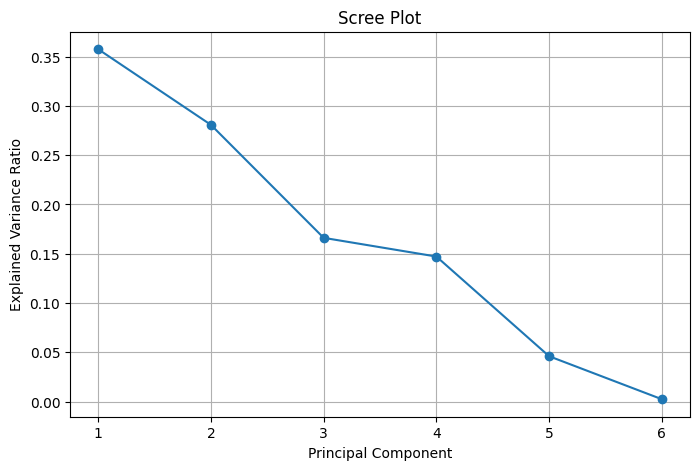

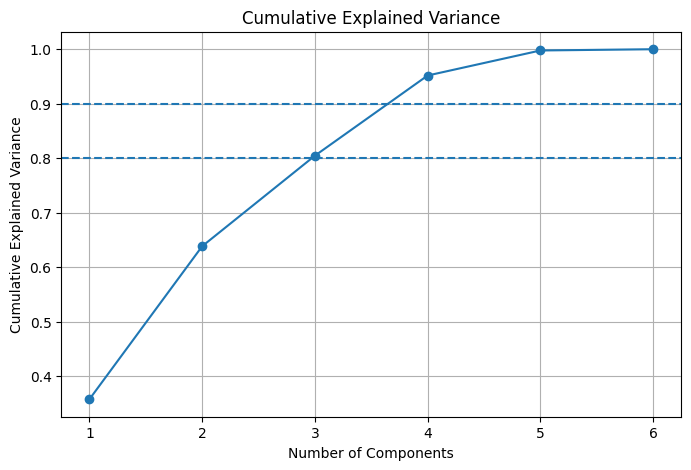

In [ ]:
from sklearn.decomposition import PCA

# 1. PCA 적합
pca = PCA(n_components=X_scaled.shape[1], random_state=42)
pca.fit(X_scaled)

# 2. 설명분산 비율 표로 정리
pca_summary = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Explained_Variance_Ratio': pca.explained_variance_ratio_,
    'Cumulative_Explained_Variance': np.cumsum(pca.explained_variance_ratio_)
})

print(pca_summary)

# 3. Scree Plot
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker='o'
)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.grid(True)
plt.show()

# 4. 누적 설명분산 Plot
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.axhline(y=0.8, linestyle='--')
plt.axhline(y=0.9, linestyle='--')
plt.grid(True)
plt.show()

In [ ]:
# 1. PCA 4개 주성분으로 변환
pca_4 = PCA(n_components=4, random_state=42)
X_pca = pca_4.fit_transform(X_scaled).astype(np.float32)

# 2. 설명분산 확인
pca_4_summary = pd.DataFrame({
    'PC': ['PC1', 'PC2', 'PC3', 'PC4'],
    'Explained_Variance_Ratio': pca_4.explained_variance_ratio_,
    'Cumulative_Explained_Variance': np.cumsum(pca_4.explained_variance_ratio_)
})

print(pca_4_summary)
print("\nX_pca shape:", X_pca.shape)

    PC  Explained_Variance_Ratio  Cumulative_Explained_Variance
0  PC1                  0.357614                       0.357614
1  PC2                  0.280839                       0.638453
2  PC3                  0.166139                       0.804592
3  PC4                  0.147148                       0.951740

X_pca shape: (3653447, 4)


In [ ]:
# PCA에 들어간 원래 변수명
scale_cols = [
    'LOG_TOTAL_SPEND',
    'VINTAGE',
    'LOG_AVG_TICKET',
    'RECENCY_DAYS',
    'LOG_AVG_LTM_SPEND',
    'LOG_AVG_LTM_TXN_COUNT'
]

# 3. 로딩값 테이블
loading_df = pd.DataFrame(
    pca_4.components_.T,
    index=scale_cols,
    columns=['PC1', 'PC2', 'PC3', 'PC4']
)

print(loading_df.round(4))

                          PC1     PC2     PC3     PC4
LOG_TOTAL_SPEND       -0.2289  0.6634 -0.0365 -0.1253
VINTAGE               -0.4202  0.3694 -0.0423 -0.5770
LOG_AVG_TICKET        -0.1664  0.4697  0.0416  0.7797
RECENCY_DAYS          -0.0592 -0.0013  0.9963 -0.0558
LOG_AVG_LTM_SPEND      0.5987  0.3464  0.0450 -0.0381
LOG_AVG_LTM_TXN_COUNT  0.6176  0.2878  0.0208 -0.1973


In [18]:
sample_n = min(100000, X_pca.shape[0])
rng = np.random.default_rng(42)
sample_idx = rng.choice(X_pca.shape[0], size=sample_n, replace=False)

X_pca_sample = X_pca[sample_idx]

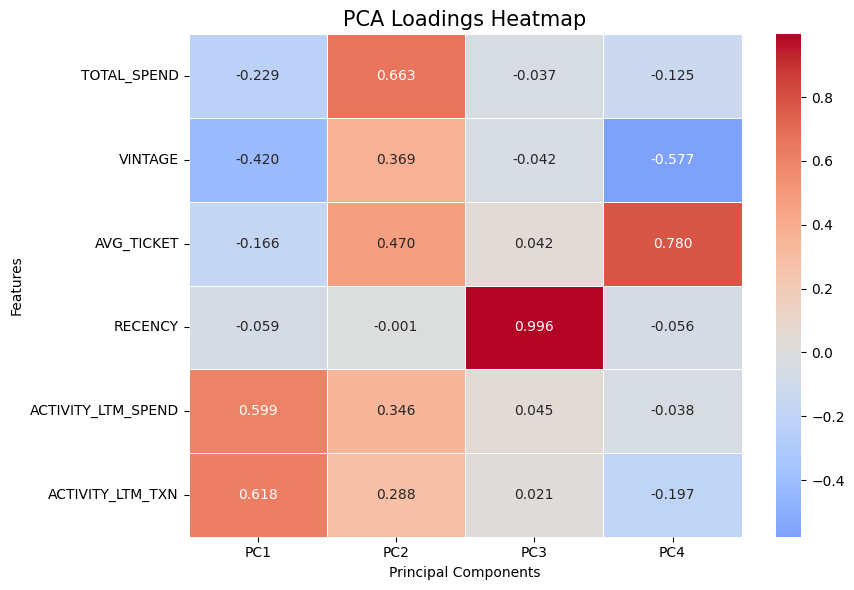

In [20]:
# PCA에 넣은 원래 변수명
feature_names = [
    'TOTAL_SPEND',
    'VINTAGE',
    'AVG_TICKET',
    'RECENCY',
    'ACTIVITY_LTM_SPEND',
    'ACTIVITY_LTM_TXN'
]

# 로딩값 데이터프레임 생성
loading_df = pd.DataFrame(
    pca_4.components_.T,
    index=feature_names,
    columns=['PC1', 'PC2', 'PC3', 'PC4']
)

# 히트맵 시각화
plt.figure(figsize=(9, 6))
sns.heatmap(
    loading_df,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('PCA Loadings Heatmap', fontsize=15)
plt.xlabel('Principal Components')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

엘보우용 샘플 shape: (100000, 4)
k=2, inertia=393565.19
k=3, inertia=300529.78
k=4, inertia=258028.42
k=5, inertia=224631.86
k=6, inertia=201853.66
k=7, inertia=183626.50
k=8, inertia=169559.20
k=9, inertia=158472.27
k=10, inertia=149898.84


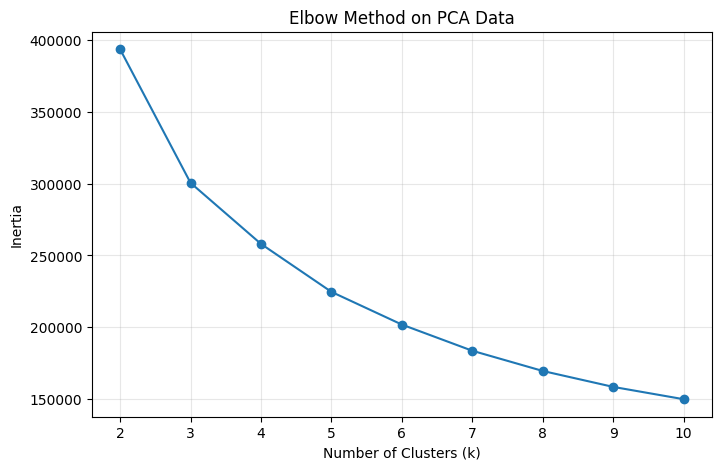

In [ ]:
from sklearn.cluster import KMeans

# 1. 엘보우용 샘플 추출
sample_n = min(100000, X_pca.shape[0])
rng = np.random.default_rng(42)
sample_idx = rng.choice(X_pca.shape[0], size=sample_n, replace=False)

X_pca_elbow = X_pca[sample_idx]

print("엘보우용 샘플 shape:", X_pca_elbow.shape)

# 2. k별 inertia 계산
k_range = range(2, 11)
inertias = []

for k in k_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(X_pca_elbow)
    inertias.append(km.inertia_)
    print(f"k={k}, inertia={km.inertia_:.2f}")

# 3. 엘보우 plot
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method on PCA Data')
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from sklearn.cluster import MiniBatchKMeans

# 1. k=4 군집화
kmeans_4 = MiniBatchKMeans(
    n_clusters=4,
    random_state=42,
    batch_size=10000,
    n_init=10
)

cluster_labels_4 = kmeans_4.fit_predict(X_pca)

print("군집 라벨 shape:", cluster_labels_4.shape)
print("군집별 고객 수:")
print(pd.Series(cluster_labels_4).value_counts().sort_index())

군집 라벨 shape: (3653447,)
군집별 고객 수:
0     465002
1    1241529
2     960944
3     985972
Name: count, dtype: int64


In [23]:
customer_k4 = customer_df.copy()
customer_k4['CLUSTER_K4'] = cluster_labels_4

print(customer_k4[['ACCOUNT_ID', 'CLUSTER_K4']].head())

        ACCOUNT_ID  CLUSTER_K4
2009463   A1000001           1
4288276   A1000004           3
4276115   A1000005           0
4211388   A1000006           3
3782438   A1000011           1


In [24]:
cluster_summary_k4 = customer_k4.groupby('CLUSTER_K4')[[
    'TOTAL_SPEND',
    'VINTAGE',
    'AVG_TICKET',
    'RECENCY_DAYS',
    'AVG_LTM_SPEND',
    'AVG_LTM_TXN_COUNT'
]].agg(['mean', 'median', 'count'])

print(cluster_summary_k4)

              TOTAL_SPEND                         VINTAGE                  \
                     mean      median    count       mean median    count   
CLUSTER_K4                                                                  
0           136827.244724   76515.175   465002  54.767586   57.0   465002   
1            32289.370228   27802.300  1241529  22.156651   19.0  1241529   
2           279411.392151  123370.330   960944  59.959710   62.0   960944   
3            60472.855016   50972.075   985972  27.569460   24.0   985972   

           AVG_TICKET                     RECENCY_DAYS                  \
                 mean     median    count         mean median    count   
CLUSTER_K4                                                               
0           50.610996  44.037442   465002    83.742644   82.0   465002   
1           33.920728  31.164866  1241529    53.161789   48.0  1241529   
2           49.803074  43.291480   960944    68.261005   62.0   960944   
3           51.0

In [25]:
cluster_size_k4 = customer_k4['CLUSTER_K4'].value_counts().sort_index()
cluster_ratio_k4 = (cluster_size_k4 / len(customer_k4) * 100).round(2)

cluster_info_k4 = pd.DataFrame({
    'count': cluster_size_k4,
    'ratio_%': cluster_ratio_k4
})

print(cluster_info_k4)

              count  ratio_%
CLUSTER_K4                  
0            465002    12.73
1           1241529    33.98
2            960944    26.30
3            985972    26.99


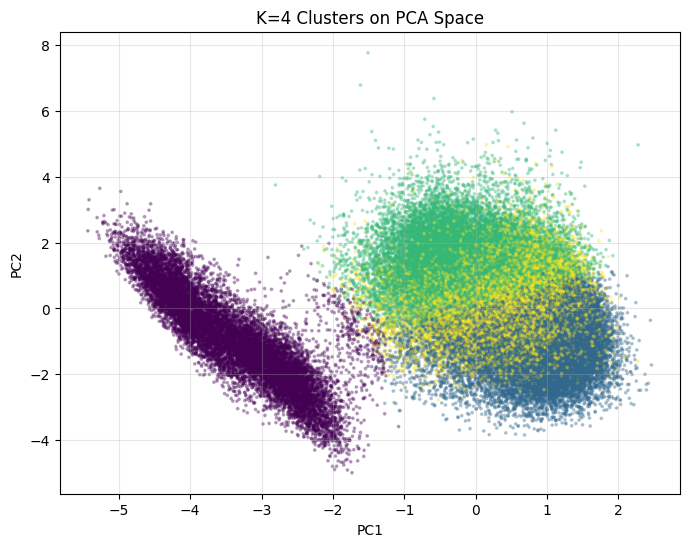

In [ ]:
sample_n = min(100000, X_pca.shape[0])
rng = np.random.default_rng(42)
sample_idx = rng.choice(X_pca.shape[0], size=sample_n, replace=False)

X_pca_sample = X_pca[sample_idx]
labels_sample = cluster_labels_4[sample_idx]

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca_sample[:, 0],
    X_pca_sample[:, 1],
    c=labels_sample,
    s=3,
    alpha=0.3
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K=4 Clusters on PCA Space')
plt.grid(alpha=0.3)
plt.show()

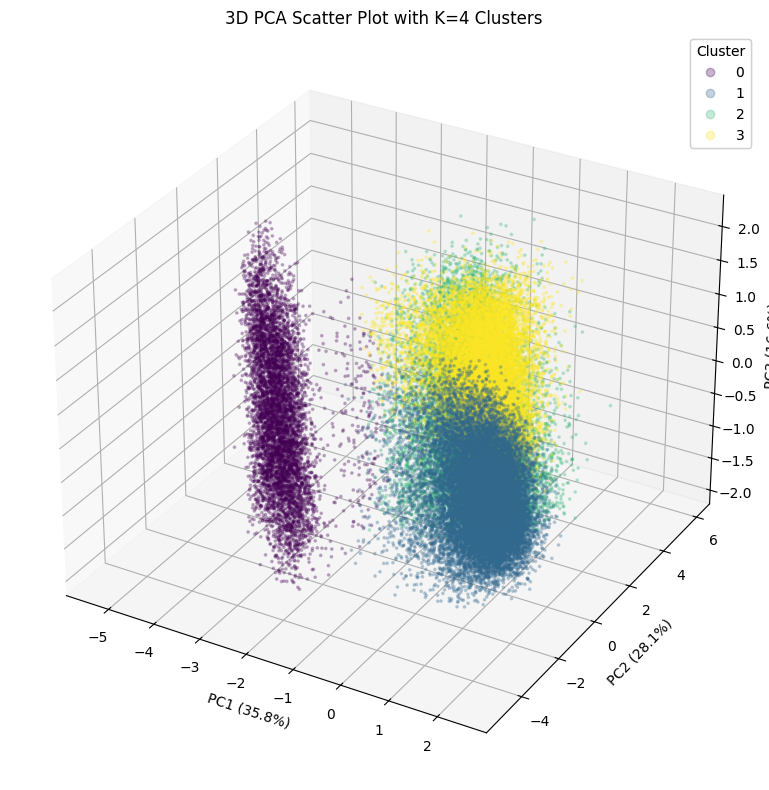

In [ ]:
# 1. 시각화용 샘플 추출
sample_n = min(50000, X_pca.shape[0])  
rng = np.random.default_rng(42)
sample_idx = rng.choice(X_pca.shape[0], size=sample_n, replace=False)

X_pca_sample = X_pca[sample_idx]
labels_sample = cluster_labels_4[sample_idx]

# 2. 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca_sample[:, 0],
    X_pca_sample[:, 1],
    X_pca_sample[:, 2],
    c=labels_sample,
    s=3,
    alpha=0.25
)

ax.set_xlabel(f'PC1 ({pca_4.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_4.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca_4.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_title('3D PCA Scatter Plot with K=4 Clusters')

legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)

plt.tight_layout()
plt.show()

In [31]:
# PCA 점수 데이터프레임
pca_score_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2', 'PC3', 'PC4']
)

# 군집 라벨 붙이기
pca_score_df['Cluster'] = cluster_labels_4

# 군집별 평균 PCA 점수
cluster_pca_mean = pca_score_df.groupby('Cluster')[['PC1', 'PC2', 'PC3', 'PC4']].mean()

print(cluster_pca_mean)

              PC1       PC2       PC3       PC4
Cluster                                        
0       -3.359147 -0.898348 -0.162210  0.297330
1        0.883025 -0.824294 -0.514681  0.019925
2       -0.038875  1.351595 -0.299864 -0.539135
3        0.510223  0.144336  1.016835  0.360134


<Figure size 1000x600 with 0 Axes>

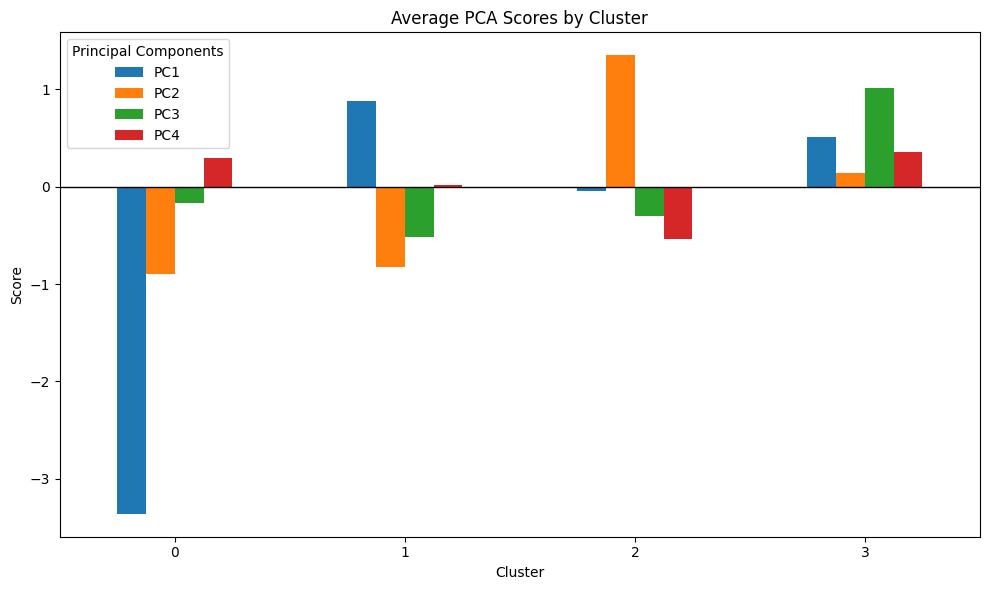

In [32]:
plt.figure(figsize=(10, 6))
cluster_pca_mean.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.axhline(0, color='black', linewidth=1)
plt.title('Average PCA Scores by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Score')
plt.legend(title='Principal Components')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

| 클러스터 | 주요 특징 | 소비/활동 특성 | 시사점 |
|---|---|---|---|
| Cluster 0 (12.73%) | 장기보유 저활동 전환형 | VINTAGE와 누적 소비액은 높은 편이나, 최근 1년 평균 소비와 거래활동은 매우 낮음 | 과거에는 일정 수준 이상 이용했으나 최근 활동성이 크게 둔화된 고객군 | 휴면 전환 가능성이 있는 고객으로, 재활성화 캠페인 및 맞춤형 리텐션 전략 필요 |
| Cluster 1 (33.98%) | 젊은 소액 일상활동형 | 최근성이 가장 우수하고 최근 1년 활동성이 높으며, 객단가와 누적 소비 규모는 가장 낮음 | 소액·빈번한 일상 소비 중심의 젊은 활동 고객군 | 일상 결제 혜택, 생활밀착형 프로모션, 멤버십 강화로 이용 습관 고착화 필요 |
| Cluster 2 (26.30%) | 장기 우량 핵심고객형 | TOTAL_SPEND, VINTAGE, 최근 1년 평균 소비·거래 모두 가장 높음 | 장기간 유지되며 현재도 활발히 이용하는 핵심 고가치 고객군 | VIP 관리, 충성도 프로그램, 프리미엄 혜택 제공을 통한 장기 유지 전략 필요 |
| Cluster 3 (26.99%) | 최근 둔화 이탈위험형 | 최근 1년 활동은 존재하나 RECENCY가 가장 나쁘고, 객단가는 비교적 높음 | 소비 여력은 있으나 최근 이용 빈도가 줄어든 이탈 위험 고객군 | 이탈 방지 프로모션, 재방문 유도 캠페인, 시점 맞춤형 리마인드 전략 필요 |


In [ ]:
from sklearn.metrics import silhouette_score

# 1. silhouette용 샘플 추출
sil_sample_n = min(30000, X_pca.shape[0])
rng = np.random.default_rng(42)
sil_idx = rng.choice(X_pca.shape[0], size=sil_sample_n, replace=False)

X_sil = X_pca[sil_idx]
labels_sil = cluster_labels_4[sil_idx]

# 2. silhouette score 계산
sil_score = silhouette_score(X_sil, labels_sil)

print("Silhouette Coefficient:", round(sil_score, 4))

Silhouette Coefficient: 0.2514


In [ ]:
# 1. 원본 df / 군집 결과용 customer_k4 복사
df_final = df.copy()
cluster_map = customer_k4[['ACCOUNT_ID', 'CLUSTER_K4']].copy()

# 2. ACCOUNT_ID 타입 맞추기
df_final['ACCOUNT_ID'] = df_final['ACCOUNT_ID'].astype(str).str.strip()
cluster_map['ACCOUNT_ID'] = cluster_map['ACCOUNT_ID'].astype(str).str.strip()

# 3. 혹시 customer_k4에 중복 ACCOUNT_ID가 있으면 제거
cluster_map = cluster_map.drop_duplicates(subset='ACCOUNT_ID')

# 4. 원본 df에 군집 라벨 붙이기
df_final = df_final.merge(
    cluster_map,
    on='ACCOUNT_ID',
    how='left'
)

# 5. 확인
print("df_final 행 수:", len(df_final))
print("군집 결측치 수:", df_final['CLUSTER_K4'].isna().sum())
print("\n군집별 거래행 수")
print(df_final['CLUSTER_K4'].value_counts(dropna=False).sort_index())

print("\n군집별 고유 ACCOUNT_ID 수")
print(df_final.groupby('CLUSTER_K4')['ACCOUNT_ID'].nunique())

df_final 행 수: 4639120
군집 결측치 수: 0

군집별 거래행 수
CLUSTER_K4
0     583532
1    1660985
2    1295535
3    1099068
Name: count, dtype: int64

군집별 고유 ACCOUNT_ID 수
CLUSTER_K4
0     465002
1    1241529
2     960944
3     985972
Name: ACCOUNT_ID, dtype: int64


In [39]:
df_final.head()

,ACCOUNT_ID,CARD_ID,TRANSACTION_ID,GROSS_TRANSACTION_AMOUNT,TRANSACTION_DATE,TRANSACTION_TYPE,TRANSACTION_STATE,TRANSACTION_CITY,MERCHANT_STATE,MERCHANT_CITY,...,CARD_HOLDER_VINTAGE,CARD_PRESENT_INDICATOR,MERCHANT_ID,MERCHANT_NAME,SHOPPER_CLASSIFICATION,TZ_NAME,LOCAL_TIME,Hour,DayOfWeek,CLUSTER_K4
0,A6184793,C7717436,T8535582,0.99,2024-03-13 06:46:55+00:00,Spend,OH,EUCLID,OH,WESTLAKE,...,29,Card Not Present,112,WENDYS,0,America/New_York,2024-03-13 02:46:55,2,Wednesday,1
1,A2296562,C5518346,T2383075,22.76,2024-05-16 20:34:18+00:00,Spend,MI,FORT GRATIOT,MI,FORT GRATIOT,...,87,Card Present,214,JIMMY JOHNS GOURMET SANDWICHES,2,America/New_York,2024-05-16 16:34:18,16,Thursday,0
2,A5523719,C7179772,T7494465,8.84,2024-04-25 17:09:37+00:00,Spend,OH,TOLEDO,OH,TOLEDO,...,25,Card Present,58,SUBWAY,0,America/New_York,2024-04-25 13:09:37,13,Thursday,1
3,A7905524,C1779514,T5897261,8.78,2024-05-26 13:50:06+00:00,Spend,IN,LAFAYETTE,IN,LAFAYETTE,...,26,Card Not Present,37,MCDONALDS,0,America/New_York,2024-05-26 09:50:06,9,Sunday,0
4,A7846687,C8240547,T2709494,18.01,2024-05-05 19:54:35+00:00,Spend,MN,DELANO,MN,DELANO,...,10,Card Present,522,CULVERS,0,America/Chicago,2024-05-05 14:54:35,14,Sunday,1


In [40]:
df_final.to_csv('df_final.csv', index=False, encoding='utf-8-sig')